# Notebook 02 — Bilateral Shape PCA

> **Supplementary §4**

This notebook runs PCA on the full bilateral marker shape (both wings and tail) to identify the dominant patterns of correlated movement. This initial PCA serves two purposes:
1. Identify that wing lifting and wing spreading are the dominant, bilaterally symmetric motions.
2. Save the results for use in the rotation correction step (Notebook 03).

## Contents
1. [Setup](#setup)
2. [Data loading and processing](#data-loading-and-processing)
3. [Visualising the markers](#visualising-the-markers)
4. [Running bilateral PCA](#running-bilateral-pca)
5. [Variance explained](#variance-explained)
6. [Interpreting the components](#interpreting-the-components)
7. [Cross-bird consistency](#cross-bird-consistency)
8. [Limitations and next steps](#limitations-and-next-steps)

In [1]:
# --- Setup ---
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format='retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Andale Mono'
np.set_printoptions(suppress=True)

from morphing_birds import Animal3D, plot_plotly, animate_plotly

from kinematic_morphospace import (
    load_data, remove_frames, scale_data, process_data,
    add_turn_info, add_tailpack_data,
    filter_by, run_PCA, run_PCA_birds,
    get_score_df, get_score_range,
    reconstruct,
)
from kinematic_morphospace.plotting import (
    plot_raw_markers, plot_3d_scatter_with_animation,
    plot_explained,
    plot_score_multi_PCs, compare_coeffs_hawks,
    save_figure,
)

## Data Loading and Processing

We load the bilateral marker data (8 feather markers × 3 coordinates = 24 variables) and apply the following processing:

1. **Load** the raw bilateral marker CSV.
2. **Remove** non-flying frames (post-landing, pre-takeoff).
3. **Scale** marker positions by each hawk's maximum wingspan per year.
4. **Process** into a NumPy array (markers) and metadata DataFrame.
5. **Add** obstacle turn direction and tailpack data.

The tailpack (central tail position) is added as a 9th marker, increasing the dimensionality to 27 (9 × 3).

In [2]:
# Load raw bilateral marker data
data_csv = load_data("../../data/2024-03-24-FullBilateralMarkers.csv")
data_csv = remove_frames(data_csv)

# Scale to maximum wingspan
wingspan_path = "../../src/kinematic_morphospace/TotalWingspans.yml"
data_csv = scale_data(data_csv, wingspan_path)

# Process into arrays
markers, frame_info, markers_df, frame_info_df = process_data(data_csv)
print(f"Markers shape: {markers.shape}")  # (N, 8, 3)
print(f"Frames: {len(frame_info_df):,}")

# Add obstacle turn info
turn_csv = "../../data/2024-06-01-ObstacleTurnsSeqList.csv"
frame_info_df = add_turn_info(frame_info_df, turn_csv)

# Add tailpack marker, scaled by wingspan to match the wing markers
markers_with_tailpack, combined_frame_info_df = add_tailpack_data(
    markers_df, frame_info_df, "../../data/2024-06-11-tailpack.csv",
    wingspan_path=wingspan_path,
)
print(f"Markers with tailpack shape: {markers_with_tailpack.shape}")  # (N, 9, 3)
print(f"Combined frames: {len(combined_frame_info_df):,}")

# Save processed data for subsequent notebooks
np.save("../../data/processed/scaled_markers.npy", markers)
np.save("../../data/processed/scaled_markers_with_tailpack.npy", markers_with_tailpack)
combined_frame_info_df.to_csv("../../data/processed/combined_frame_info_df.csv", index=False)

Starting with 155866 frames.
Removed frames with time less than 0. This removes frames before takeoff jump.
-- Number of frames removed: 2426
Detected mostly positive HorzDistance values. Flipping the sign.
Removed frames with horizontal distance greater than 0.1.
-- Number of frames removed: 0
Now 153053 frames.
Loaded total wingspans from TotalWingspans.yml
-- Drogon max wingspan estimated at {2017: 1.0083, 2020: 1.0159}
-- Rhaegal max wingspan estimated at {2017: 1.0193}
-- Ruby max wingspan estimated at {2017: 1.0783, 2020: 1.0613}
-- Toothless max wingspan estimated at {2017: 1.0607, 2020: 1.0641}
-- Charmander max wingspan estimated at {2020: 1.0164}
Scaled the data.
Cleaned marker names.
Loaded frame info and cleaned columns.
Data verified.
Markers shape: (153053, 8, 3)
Frames: 153,053
Added turn direction to dataframe.
Original number of markers: 8


Merging frame info with markers DataFrame. Frame info: (153053, 13), New df: (939383, 4)


Removed 797048 rows out of (941812, 16) with NaN values.
Rows in frame_info_df not in merged df: 8289
Scaled tailpack data by wingspan.
Markers with tailpack shape: (144764, 9, 3)
Combined frames: 144,764


## Visualising the Markers

Before running PCA, we visualise the raw marker positions to understand the data. All positions are relative to the backpack (centre of mass proxy), with estimated body pitch removed. The origin is at the backpack.

In [3]:
# Plot 3D scatter for a single hawk (Charmander, 9 m, 2020)
filt = filter_by(combined_frame_info_df, hawkname="Charmander", perchDist=9, year=2020)
subset = markers_with_tailpack[filt]
n_flights = combined_frame_info_df[filt]["seqID"].nunique()
print(f"Charmander, 9 m, 2020: {len(subset):,} frames from {n_flights} flights")

x = subset[:, :, 0].flatten()
y = subset[:, :, 1].flatten()
z = subset[:, :, 2].flatten()
_ = plot_3d_scatter_with_animation(x, y, z, browser=False)

Charmander, 9 m, 2020: 9,396 frames from 121 flights


### Mean Shape

The average marker positions across all frames define the mean hawk shape, which serves as the reference for PCA. The `Animal3D` object renders a 3D hawk model using polygon surfaces connecting the markers. Blue polygons are data-driven; grey polygons are from scaled photograph references.

In [4]:
# Plot the mean hawk shape
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')
mean_markers = np.mean(markers_with_tailpack, axis=0)
hawk3d.update_keypoints(mean_markers[:8].reshape(1, 8, 3)) # We skip the tailpack for this plot since the mean shape doesn't include it
plot_plotly(hawk3d)

## Running Bilateral PCA

> **§4 — Principal Component Analysis**

PCA identifies linear combinations that capture the maximum variance in the data. Here, PCA reveals the dominant morphing patterns in flight and coupled motions of the wings and tail — a data-driven approach to finding structured relationships without predefined assumptions.

### Mathematical framework

The covariance matrix captures how the marker coordinates co-vary:

$$C = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \mu)(x_i - \mu)^T$$

The eigenvalue problem $C v = \lambda v$ yields eigenvectors $v$ (principal component directions) and eigenvalues $\lambda$ (variance explained by each component).

The proportion of variance explained by each component is:

$$V = \frac{\lambda}{\sum \lambda}$$

To transform data into the principal component space and obtain scores:

$$S = P^T (x - \mu)$$

where $P$ is the loadings matrix (eigenvectors as columns), $x$ is the original data, and $\mu$ is the mean shape.

To reconstruct from scores back to the original space:

$$\hat{x} = P_k S_k + \mu$$

where $P_k$ and $S_k$ use only the first $k$ components.

### Training vs projection

PCA is fitted on **non-obstacle flights only** (to avoid obstacle-induced turning behaviour biasing the components) and projected onto **all data** including obstacle flights. This preserves the unbiased component definitions whilst allowing the full dataset to be described in the same coordinate space.

### Why no z-score normalisation?

All marker coordinates share the same spatial unit (metres, normalised to wingspan). Z-score normalisation would distort the spatial relationships between markers — for example, making a small z-movement of the tail appear as important as a large z-movement of the wingtip. We therefore use raw (wingspan-scaled) coordinates (§4.1).

In [5]:
# Fit PCA on non-obstacle flights, project onto all data
filt = filter_by(combined_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(
    markers_with_tailpack[filt], markers_with_tailpack
)

n_features = markers_with_tailpack.shape[1] * markers_with_tailpack.shape[2]
print(f"Input dimensionality: {markers_with_tailpack.shape[1]} markers × {markers_with_tailpack.shape[2]} coords = {n_features} features")
print(f"Training frames (non-obstacle): {filt.sum():,}")
print(f"Projected frames (all): {scores.shape[0]:,}")
print(f"Number of components: {scores.shape[1]}")
print(f"\nCumulative variance explained:")
cev = np.cumsum(pca.explained_variance_ratio_)
for i in range(min(10, len(cev))):
    print(f"  PC 1-{i+1}: {cev[i]:.4f} ({cev[i]:.1%})")

# Save PCA results for Notebook 03
np.save("../../data/processed/whole_body_pca_results.npy",
        {"principal_components": principal_components,
         "scores": scores,
         "pca_mean": pca.mean_},
        allow_pickle=True)

Input dimensionality: 9 markers × 3 coords = 27 features
Training frames (non-obstacle): 126,315
Projected frames (all): 144,764
Number of components: 27

Cumulative variance explained:
  PC 1-1: 0.6089 (60.9%)
  PC 1-2: 0.8368 (83.7%)
  PC 1-3: 0.8772 (87.7%)
  PC 1-4: 0.9137 (91.4%)
  PC 1-5: 0.9355 (93.6%)
  PC 1-6: 0.9508 (95.1%)
  PC 1-7: 0.9603 (96.0%)
  PC 1-8: 0.9685 (96.8%)
  PC 1-9: 0.9735 (97.3%)
  PC 1-10: 0.9775 (97.7%)


## Variance Explained

The cumulative explained variance shows how quickly the variance concentrates in the first few components. The first component (wing lifting) alone explains > 60% of the variance; the first three components capture > 87%.

Saved: ../../figures/supplementary/S05_bilateral_variance.pdf


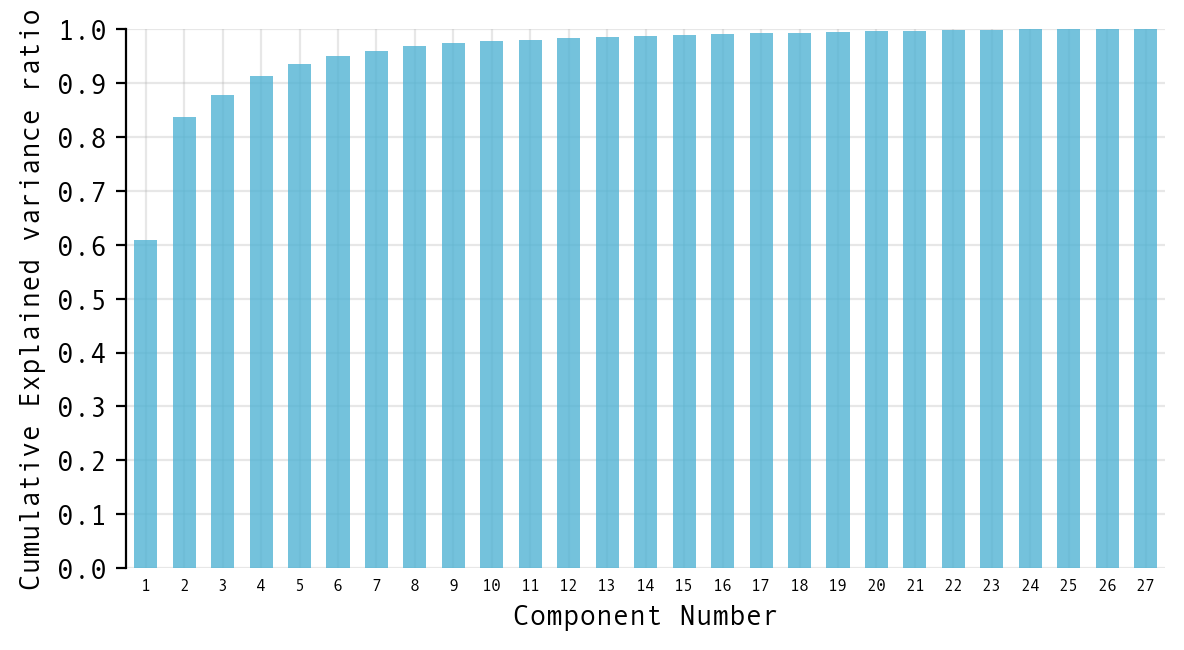

In [6]:
ax = plot_explained(pca.explained_variance_ratio_, colour_before=0, annotate=False)
save_figure(ax, '../../figures/supplementary/S05_bilateral_variance.pdf')

## Interpreting the Components

We visualise each component by sweeping its score between the observed minimum and maximum, reconstructing the hawk shape at each step. This reveals the physical motion pattern each component captures.

**Key findings:**
- **PC 1** — Raising and lowering of the wings (flapping). The tail also moves, indicating correlated bounce from wing motion.
- **PC 2** — Spreading and contracting of the wings, with correlated tail spread.
- **PC 3+** — Contaminated by whole-body rotation (especially roll). This is why rotation correction is needed before extracting morphing shape modes.

**Important:** Single-component reconstructions do not represent realistic hawk shapes. Components must combine to produce real morphing configurations.

In [7]:
# Animate a selected component (change PC_number to explore)
hawk3d = Animal3D('hawk', '../../data/mean_hawk_shape.csv')
mu = pca.mean_.reshape(1, markers_with_tailpack.shape[1], 3)
score_frames = get_score_range(scores, num_frames=25)

colour_list = ['#B5E675', '#6ED8A9', '#51B3D4',
               '#4579AA', '#BC96C9', '#917AC2',
               '#5A488B', '#888888', '#888888',
               '#888888', '#888888', '#888888']

PC_number = 1  # Change to explore other components
hawk3d.reset_transformation()
hawk3d.restore_keypoints_to_average()
hawk3d.update_keypoints(mu[:, 0:8, :])

component_index = [PC_number - 1]
reconstructed_frames = reconstruct(score_frames, principal_components, mu, component_index)
reconstructed_frames = reconstructed_frames[:, :-1, :]  # Remove tailpack for animation

print(f"PC {PC_number}: score range [{np.min(score_frames):.2f}, {np.max(score_frames):.2f}]")
animate_plotly(hawk3d, reconstructed_frames, colour=colour_list[PC_number - 1],
               score_vals=score_frames[:, component_index])

PC 1: score range [-0.61, 0.61]


### Score Traces over a Flight

The scores for each component can be plotted against horizontal distance to perch, showing how the morphing pattern evolves during a flight.

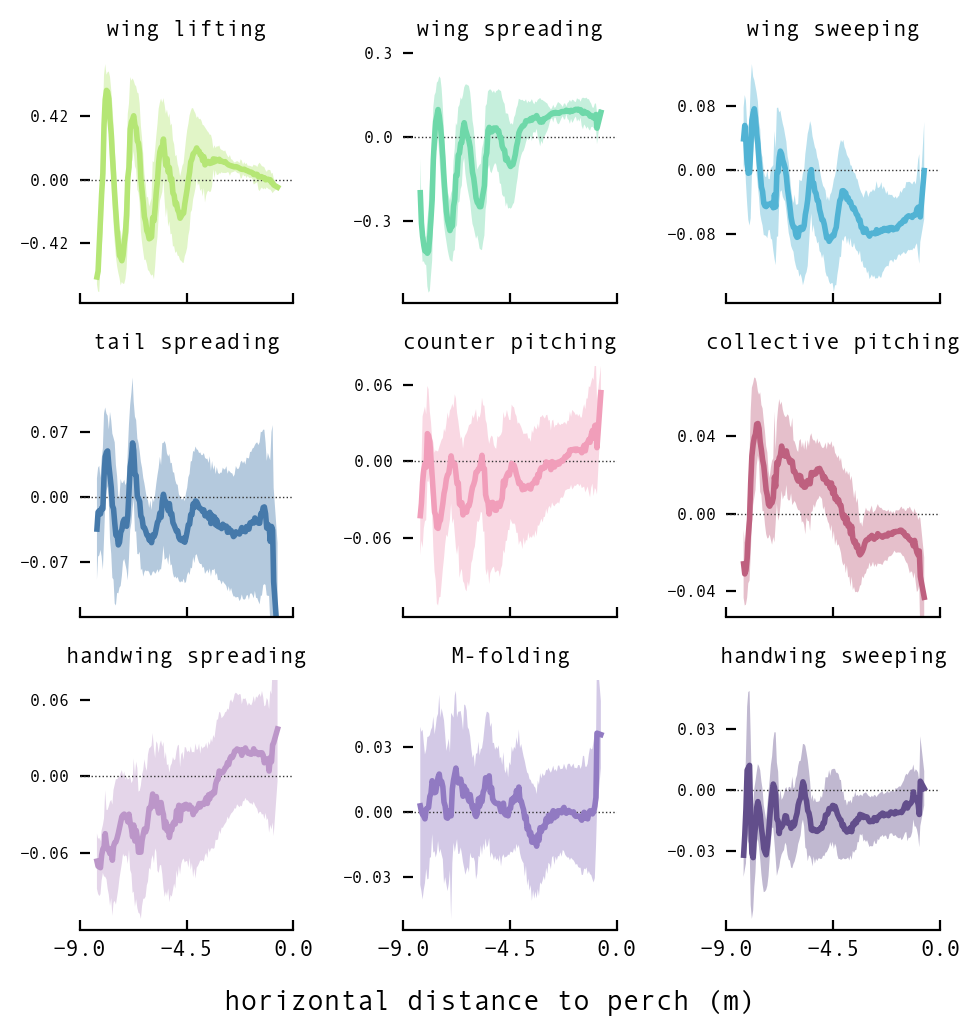

In [8]:
scores_df, horz_dist_bins = get_score_df(scores, combined_frame_info_df, size_bin=0.05)
plot_score_multi_PCs(scores_df, PC_num_list=range(1, 10),
                     perchDist=9, hawkname="Toothless",
                     turn="Straight", year=2020)
plt.show()

## Cross-Bird Consistency

We verify that the principal components are consistent across individuals by running PCA per bird and comparing the loadings against a reference (Toothless, which has the most data).

If components are identical across birds, the comparison matrix would show a perfect diagonal. Shading off-diagonal indicates shared information between components.

Toothless data is consistent.
Toothless diagonal values are close to 1, same matrix.


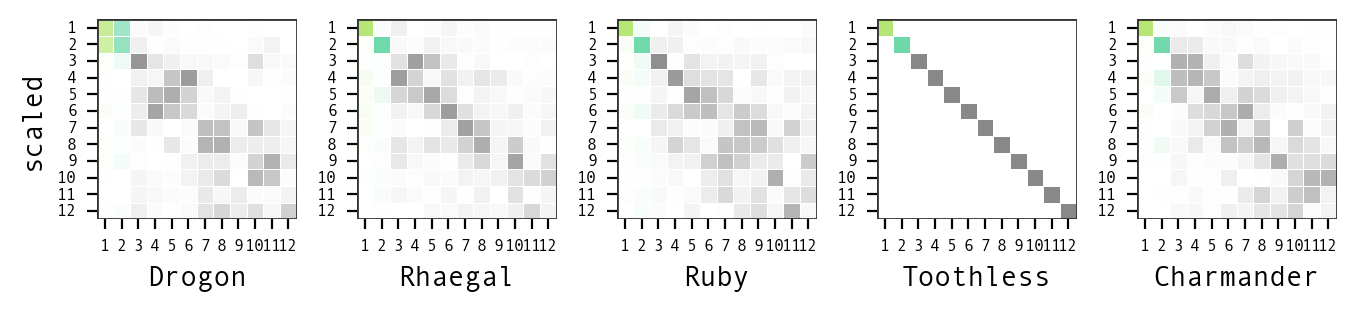

In [9]:
# Re-run PCA for consistency check (non-obstacle flights)
filt = filter_by(combined_frame_info_df, obstacle=0)
principal_components, scores, pca = run_PCA(
    markers_with_tailpack[filt], markers_with_tailpack
)
components_by_bird = run_PCA_birds(markers_with_tailpack, combined_frame_info_df)

fig = compare_coeffs_hawks(
    components_by_bird['Toothless'], components_by_bird,
    colour_before=2, y_label='scaled'
)
plt.show(fig)

## Limitations and Next Steps

The bilateral PCA has two key limitations:

1. **Bilateral data reduces statistical power.** Left–right asymmetry and variation must be described by the components, weakening the ability to find meaningful morphing patterns. The left and right sides of the wings are expected to be more independent than markers within the same wing.

2. **Whole-body rotation contaminates higher components.** Roll, yaw, and residual pitch appear as correlated changes in marker positions, mixing with intrinsic morphing patterns. This is clearly visible from PC 3 onwards.

**Next step:** In Notebook 03, we use the first two (symmetric) components to estimate and remove whole-body rotation, then in Notebook 04 we run PCA on unilateral (single-side) data to extract the true morphing shape modes.

---

## References

- Jolliffe, I. T. (2002). *Principal Component Analysis* (2nd ed.). Springer-Verlag.
- Daffertshofer, A., Lamoth, C. J. C., Meijer, O. G. & Beek, P. J. (2004). PCA in studying coordination and variability. *Clinical Biomechanics*, 19, 415–428.
- Riskin, D. K. et al. (2008). Quantifying the complexity of bat wing kinematics. *Journal of Theoretical Biology*, 254, 604–615.